# Retrieval-Augmented Generation

**Core concepts:** grounding a model in supplied context, chunking, vector indexes,
the retrieve-then-generate loop, citation, retrieval failure versus generation failure,
evaluating the two halves separately

**Tools:** `sentence-transformers`, HuggingFace `transformers`, NumPy, pandas

**Models covered:** all-MiniLM-L6-v2 for retrieval, Qwen3-1.7B for generation

The Introduction to Generative AI notebook showed a model inventing confident
answers about things it had never seen. The
prompt engineering notebook improved the instructions but not the information. RAG fixes
the information: find the relevant text first, put it in the prompt, and require the answer
to come from it.

Nothing here is a new idea. It is the Introduction to Generative AI notebook's semantic search joined to the
Prompt Engineering notebook's prompting.

**Runtime:** roughly 15 minutes on a Colab T4.

## 0. The task

Amazon Fine Food Reviews once more, framed as a question-answering problem a business
actually has: **"what do customers say about this product?"**

We take one product with many reviews and build a system that answers questions about it,
grounded in the reviews and citing them. That is a genuine data science application, and it
is the shape of most internal RAG systems: a body of text nobody has time to read, and
questions about it.

## 1. Setup

In [1]:
!pip install -q transformers sentence-transformers

In [2]:
import time
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (11, 4)
print("torch:", torch.__version__, "| device:", DEVICE)

torch: 2.11.0+cu128 | device: cuda


In [3]:
MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto")
model.eval()
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(DEVICE))

print("generator and retriever loaded")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

generator and retriever loaded


In [4]:
@torch.no_grad()
def ask_model(user, system=None, max_new_tokens=160):
    "Single-turn, greedy, deterministic generation."
    msgs = ([{"role": "system", "content": system}] if system else [])
    msgs.append({"role": "user", "content": user})

    text = tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    enc = tokenizer(text, return_tensors="pt").to(model.device)

    out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0, enc["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


def show(text, width=94):
    print(textwrap.fill(text, width))

## 2. The problem RAG solves

The Introduction to Generative AI notebook measured it: the whole review dataset is many millions of tokens and the context
window holds a few tens of thousands. Even if everything fitted, sending it would be slow and
expensive, and the "lost in the middle" effect means the model would use the middle of it
poorly.

So the question is not "how do I show the model everything" but **"how do I find the small
part that matters"**. RAG is three steps:

1. **Index**: split the corpus into pieces and embed each one, once, in advance
2. **Retrieve**: embed the question, find the nearest pieces
3. **Generate**: put those pieces in the prompt and ask the model to answer from them

Step 2 is the Introduction to Generative AI notebook's section 7. Step 3 is the
Prompt Engineering notebook. The only genuinely new part is how you cut the
corpus up, and what goes wrong.

First, the failure we are fixing.

In [7]:
reviews = pd.read_csv(Path("Reviews.csv"),
                      usecols=["ProductId", "Score", "Summary", "Text"],
                      on_bad_lines="skip",
                      engine="python").dropna(subset=["Text"])

# pick a product with plenty of reviews and a mix of opinions
counts = reviews["ProductId"].value_counts()
product_id = counts[(counts >= 120) & (counts <= 400)].index[0]

product = reviews[reviews["ProductId"] == product_id].reset_index(drop=True)

print(f"product: {product_id}")
print(f"reviews: {len(product)}")
print(f"mean score: {product['Score'].mean():.2f}")
print(f"\nfirst review:\n")
show(product["Text"].iloc[0][:500])

product: B000GAT6NG
reviews: 389
mean score: 4.80

first review:

Since I have started to use this product over a year ago, I don't even try to find other
brands. I will stick with this brand of ex. virg. coconut oil for as long as I can get it. I
take at least two tbls. of this throughout the day and I use it on every food that I eat
instead of butter. This is one of the top natural cures that you can buy and it is simply a
FOOD!!


In [8]:
question = f"What do customers say about the taste of product {product_id}?"

print("WITHOUT any context:\n")
show(ask_model(question))

WITHOUT any context:

I don't have access to real-time data or customer reviews for specific products like
"B000GAT6NG." This product code likely refers to a specific item, such as a software, gadget,
or service, but I don't have information about its features, reviews, or customer feedback.
If you're looking for customer reviews or ratings, you might want to:  1. Check online review
platforms like **Amazon**, **Google Reviews**, or **Yelp**. 2. Look for product pages on
**e-commerce websites** (e.g., Amazon, eBay, or Alibaba). 3. Use review aggregation tools like
**Trustpilot** or **Reddit** to find community feedback. 4. Contact the product's customer
support for direct feedback.  Let me know if you'd like


The model has never seen this product and cannot have an opinion about it. What it produces
instead is a fluent answer shaped like the truth, which is the failure mode from the Introduction to Generative AI notebook's
section 8. Nothing about the output signals that it is invented.

## 3. Chunking

The corpus has to be split into retrievable pieces. Chunk size is a real hyperparameter with
a genuine tradeoff.

**Chunks too small** lose the context needed to make sense of them. A sentence saying "it
tastes awful" is useless without knowing what "it" is.

**Chunks too large** dilute the embedding. A single vector has to represent everything in
the chunk, so a long chunk covering five topics sits in the average of five places and is
close to none of them. Large chunks also waste context window on irrelevant text.

Here each review is a natural chunk: written as a unit, self-contained, and usually the right
size. That is a luxury. With PDFs or long documents you would split by paragraph or by a
fixed token count with overlap.

In [9]:
def chunk_text(text, chunk_tokens=120, overlap=20):
    """Split text into overlapping fixed-size chunks, measured in model tokens."""
    ids = tokenizer.encode(text)
    if len(ids) <= chunk_tokens:
        return [text]

    step = chunk_tokens - overlap
    return [tokenizer.decode(ids[i:i + chunk_tokens])
            for i in range(0, len(ids), step)
            if len(ids[i:i + chunk_tokens]) > overlap]

# Ensure 'product' exists from the previous steps before accessing it
if 'product' in globals():
    long_review = product.loc[product["Text"].str.len().idxmax(), "Text"]
    pieces = chunk_text(long_review, chunk_tokens=60, overlap=10)

    print(f"a {len(tokenizer.encode(long_review))}-token review becomes {len(pieces)} chunks\n")
    for i, p in enumerate(pieces[:3]):
        print(f"--- chunk {i}")
        show(p)
        print()
else:
    print("Error: 'product' DataFrame not found. Please ensure cell IutI2EgQzlTH has been executed.")

a 1711-token review becomes 35 chunks

--- chunk 0
When I learned about the many benefits and uses of coconut oil I had to try it, so I ordered 2
jars -one for my pantry for cooking/smoothies etc. and one for my bathroom to use as a body
cream. Since I didn't know what brand to choose and didn't

--- chunk 1
 didn't know what brand to choose and didn't have any prior experience with coconut oil I
decided to get one jar of the NUTIVA brand and one jar of the NATURE'S WAY brand.<br /><br
/>Here's my initial opinion of both: With my Nutiva jar there's a

--- chunk 2
 both: With my Nutiva jar there's a sticker indicating the expiration date and
package/creation date of the actual oil, whereas with my Nature's Way jar there's nothing like
that. When I opened both of them up to try and to just generally check them out I tasted a
tiny amount of



The **overlap** exists so that a sentence spanning a boundary is not lost. Without it, a fact
split across the cut appears in neither chunk in a usable form. Overlap costs storage and
introduces near-duplicate results, which is a fair trade.

For the rest of this notebook we treat one review as one chunk, and keep any review that is
unusually long split into pieces.

In [10]:
chunks, sources = [], []

for i, row in product.iterrows():
    for piece in chunk_text(row["Text"], chunk_tokens=200, overlap=30):
        chunks.append(piece)
        sources.append({"review_id": i, "score": row["Score"], "summary": row["Summary"]})

sources = pd.DataFrame(sources)

print(f"{len(product)} reviews -> {len(chunks)} chunks")
print(f"median chunk length: {np.median([len(tokenizer.encode(c)) for c in chunks]):.0f} tokens")

389 reviews -> 467 chunks
median chunk length: 83 tokens


**Predict, then check later.** This notebook chunks by full review, letting a review's
natural length set the chunk size. Section 8 tests two very different sizes head to head.
Before you get there: would you expect a very small chunk, a single sentence, or a very
large one, many reviews concatenated, to retrieve better for a specific factual question
like "does it taste bitter"? Why?

## 4. Index and retrieve

Embedding the corpus is a one-time cost. Queries are then a matrix multiply, which is why
retrieval is fast enough to sit in front of every request.

In [11]:
start = time.perf_counter()
chunk_emb = embedder.encode(chunks, normalize_embeddings=True,
                            batch_size=64, show_progress_bar=True)
print(f"\nindexed {len(chunks)} chunks in {time.perf_counter() - start:.1f}s")
print(f"index shape: {chunk_emb.shape}  ({chunk_emb.nbytes / 1e6:.1f} MB)")

Batches:   0%|          | 0/8 [00:00<?, ?it/s]


indexed 467 chunks in 1.3s
index shape: (467, 384)  (0.7 MB)


In [12]:
def retrieve(query, k=4, min_similarity=0.0):
    "Return the k most similar chunks above a similarity floor, with their metadata."
    q = embedder.encode([query], normalize_embeddings=True)
    sims = (q @ chunk_emb.T)[0]
    top = [i for i in np.argsort(-sims)[:k] if sims[i] >= min_similarity]

    # 'similarity' is the cosine score, 'score_star' is the reviewer's rating.
    # Keeping the names distinct avoids a confusing collision later.
    return [{"chunk": chunks[i],
             "similarity": float(sims[i]),
             "score_star": int(sources.iloc[i]["score"]),
             "summary": sources.iloc[i]["summary"],
             "review_id": int(sources.iloc[i]["review_id"])}
            for i in top]


hits = retrieve("Does this taste good?", k=3)

for h in hits:
    print(f"[similarity {h['similarity']:.3f}, rated {h['score_star']}/5: {h['summary']}]")
    show(h["chunk"][:280])
    print()

[similarity 0.627, rated 3/5: Interesting stuff]
Rather bland tasting, although I havent tried to use it in some of the suggested ways. For a
cooking oil it probably is OK. But it is expensive, so I don't think I'll buy it again.<br
/>The shipping was fast and I'll always buy other products from Amazon due to excellent
service

[similarity 0.609, rated 5/5: Good product reached on time]
Tastes good. I try using it as a substitute to butter. Also, I eat 2 Tbs daily, works as a
good nutritional supplement.

[similarity 0.606, rated 5/5: The best tasting]
This brand is the best tasting to me. I've tried others, and don't like them, (except for
Garden of Eden brand). This smells and taste like coconut. I toast sprouted bread, spread this
on it, add a little salt, and maybe some nutritional yeast. Or I use some agave nectar instead



Because the index is normalized, similarity is a cosine in the range -1 to 1. In practice
relevant chunks land somewhere around 0.4 to 0.8 and irrelevant ones below 0.2. That number
is useful: a **similarity floor** lets the system answer "I could not find anything about
that" instead of retrieving the four least-irrelevant chunks and answering from them.

In [13]:
for q in ["Does this taste good?",
          "Is the packaging recyclable?",
          "What is the capital of Brazil?"]:
    best = retrieve(q, k=1)[0]["similarity"]
    verdict = "in scope" if best > 0.25 else "OUT OF SCOPE, should refuse"
    print(f"{best:.3f}  {verdict:<28} {q}")

0.627  in scope                     Does this taste good?
0.375  in scope                     Is the packaging recyclable?
0.191  OUT OF SCOPE, should refuse  What is the capital of Brazil?


## 5. Generate, grounded

The retrieved chunks go into the prompt with instructions that constrain the model to use
them. Three instructions matter, and each prevents a specific failure:

- **Answer only from the context.** Without this the model blends supplied facts with
  training-data memories, and you cannot tell which is which
- **Say when the context is insufficient.** Otherwise it will always produce something
- **Cite the source.** Makes the answer checkable, which is the entire point

In [14]:
RAG_SYSTEM = (
    "You answer questions about a product using only the customer reviews provided. "
    "Every claim must come from the reviews. "
    "Cite the reviews you used as [1], [2] and so on. "
    "If the reviews do not contain the answer, say 'The reviews do not cover this.' "
    "Be concise."
)


def build_rag_prompt(question, hits):
    context = "\n\n".join(
        f"[{n + 1}] (rated {h['score_star']}/5) {h['chunk']}"
        for n, h in enumerate(hits))
    return f"Customer reviews:\n\n{context}\n\nQuestion: {question}\n\nAnswer:"

The whole system is now three lines: retrieve, build the prompt, generate. If retrieval
returns nothing above the similarity floor, we refuse without calling the model at all, which
is both cheaper and more reliable than asking it to refuse.

In [15]:
def rag_answer(question, k=4, min_similarity=0.25, verbose=False):
    hits = retrieve(question, k=k, min_similarity=min_similarity)

    if not hits:
        return "The reviews do not cover this.", []

    prompt = build_rag_prompt(question, hits)
    if verbose:
        print(prompt[:900], "\n---")

    return ask_model(prompt, system=RAG_SYSTEM), hits

In [16]:
answer, hits = rag_answer("What do customers say about the taste?")

print("ANSWER\n")
show(answer)

print("\n\nSOURCES")
for n, h in enumerate(hits, 1):
    print(f"  [{n}] similarity {h['similarity']:.2f}, {h['score_star']}/5: {h['summary']}")

ANSWER

Customers say the taste is good, with some noting it is "the best tasting to me" [2], "tastes
and smells so good" [4], and "really fresh tasting" [3]. The review [1] mentions it is "rather
bland tasting," but this is qualified as "probably is OK" for cooking oil. The reviews do not
cover this.


SOURCES
  [1] similarity 0.52, 3/5: Interesting stuff
  [2] similarity 0.51, 5/5: The best tasting
  [3] similarity 0.49, 5/5: product review
  [4] similarity 0.48, 5/5: Wonderful Stuff


Compare this against section 2's ungrounded answer. The claims now trace to specific reviews
you can read yourself. That is the difference between an answer and an assertion.

In [17]:
for q in ["Is it good value for the price?",
          "How does it compare to other brands?",
          "Does the company have a factory in Vietnam?"]:
    ans, hs = rag_answer(q)
    print(f"Q: {q}")
    show(f"A: {ans}")
    print(f"   ({len(hs)} chunks retrieved)\n")

Q: Is it good value for the price?
A: The reviews do not cover this.
   (4 chunks retrieved)

Q: How does it compare to other brands?
A: The reviews do not cover this.
   (4 chunks retrieved)

Q: Does the company have a factory in Vietnam?
A: The reviews do not cover this.
   (2 chunks retrieved)



The third question is deliberately unanswerable from reviews. A working system either refuses
or says the reviews do not cover it. If it invents a factory, the grounding instruction is
not holding, which section 7 examines.

### Checkpoint: ask your own question

Write two questions of your own about this product. One you expect the reviews to cover,
one you suspect they will not.

**Task**

1. Run both through `rag_answer`.
2. For each, read the sources printed alongside the answer. Does the answer actually match
   what those specific sources say?
3. If either answer looks made up rather than grounded, note it now, section 7 gives you the
   tools to diagnose why.

In [ ]:
my_question_covered = "..."      # a question you expect the reviews to answer
my_question_uncovered = "..."    # a question you suspect they will not

for q in [my_question_covered, my_question_uncovered]:
    ans, hits = rag_answer(q)
    print(f"Q: {q}")
    show(f"A: {ans}")
    for n, h in enumerate(hits, 1):
        print(f"  [{n}] similarity {h['similarity']:.2f}: {h['summary']}")
    print()

## 6. How many chunks to retrieve

`k` is the other main hyperparameter. Too few and the answer misses relevant material. Too
many and you pay for tokens, dilute the prompt, and increase the chance the model latches
onto something irrelevant.

In [18]:
question = "What are the main complaints about this product?"
rows = []

for k in [1, 2, 4, 8, 16]:
    hits = retrieve(question, k=k, min_similarity=0.0)
    context_tokens = sum(len(tokenizer.encode(h["chunk"])) for h in hits)

    start = time.perf_counter()
    ans, _ = rag_answer(question, k=k, min_similarity=0.0)
    elapsed = time.perf_counter() - start

    rows.append({"k": k, "context_tokens": context_tokens, "seconds": elapsed,
                 "min_similarity": min(h["similarity"] for h in hits)})
    print(f"k={k:>2}  {context_tokens:>5} context tokens  {elapsed:>5.1f}s  "
          f"weakest hit {rows[-1]['min_similarity']:.2f}")

k= 1     50 context tokens    0.5s  weakest hit 0.54
k= 2    164 context tokens    0.5s  weakest hit 0.49
k= 4    288 context tokens    0.5s  weakest hit 0.43
k= 8    638 context tokens    0.7s  weakest hit 0.41
k=16   1214 context tokens    1.1s  weakest hit 0.40


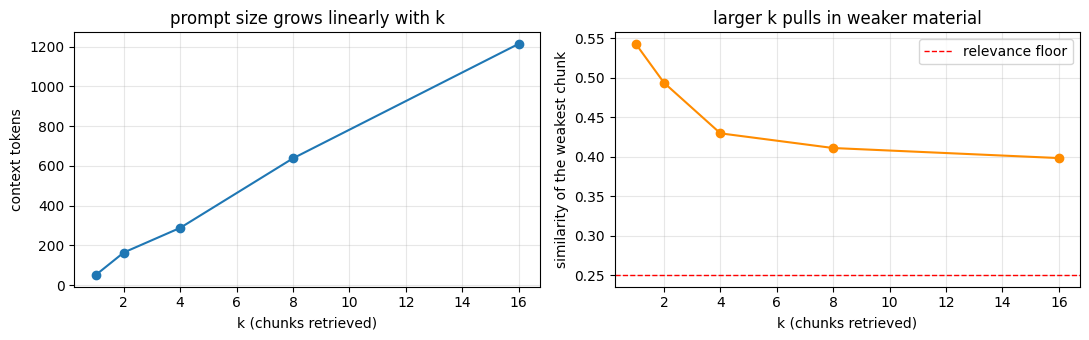

In [19]:
kdf = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(kdf["k"], kdf["context_tokens"], "o-")
axes[0].set_xlabel("k (chunks retrieved)")
axes[0].set_ylabel("context tokens")
axes[0].set_title("prompt size grows linearly with k")
axes[0].grid(alpha=0.3)

axes[1].plot(kdf["k"], kdf["min_similarity"], "o-", color="darkorange")
axes[1].axhline(0.25, color="red", ls="--", lw=1, label="relevance floor")
axes[1].set_xlabel("k (chunks retrieved)")
axes[1].set_ylabel("similarity of the weakest chunk")
axes[1].set_title("larger k pulls in weaker material")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The right panel is the argument for a similarity floor rather than a fixed `k`. As `k` grows,
the weakest retrieved chunk falls below anything that could be called relevant, and you are
paying tokens to put noise in front of the model. Retrieving "everything above 0.3, up to 8
chunks" is usually better than "always exactly 8".

## 7. Failure modes

RAG has two components and therefore two independent ways to fail. Diagnosing which one broke
is the main practical skill.

### Failure 1: retrieval missed

If the right chunk is not retrieved, the generator cannot recover. The answer will be wrong
or a refusal, and no amount of prompt tuning fixes it.

The tell is that the answer is poor but the retrieved chunks are visibly off-topic.

In [20]:
tricky = "Do people mention their pets?"
hits = retrieve(tricky, k=3, min_similarity=0.0)

print(f"Q: {tricky}\n")
for n, h in enumerate(hits, 1):
    print(f"[{n}] similarity {h['similarity']:.2f}: {h['chunk'][:150]}...\n")

ans, _ = rag_answer(tricky)
show(f"ANSWER: {ans}")

Q: Do people mention their pets?

[1] similarity 0.28:  I feed it to my dog and cat, my cat loves it - and he won't eat anything! Actually, I don't think that he can resist the smell, I can't! Another one ...

[2] similarity 0.20: Great Product for a great price! We used it all the time to cook with and add a little to our German Shepherds meal from time to time....

[3] similarity 0.20: This is my second purchase of this product.  You may think you'll never use it all, but let me tell you, it has so many uses with such great results t...

ANSWER: Yes, people mention their pets. [1]


### Failure 2: the context was retrieved but ignored

The opposite case: the right information was in the prompt and the model answered from its
training data anyway, or contradicted the context. This is where the grounding instruction
earns its place.

A direct test is to supply context that conflicts with what the model already believes. A
grounded system follows the context. An ungrounded one follows its memory.

In [21]:
fake_context = ("[1] (rated 5/5) This tea is produced exclusively on the island of "
                "Zanzibar, where the Kwenzi variety has been grown since 1823.")

conflict_q = "Where is this tea produced, according to the reviews?"

grounded = ask_model(f"Customer reviews:\n\n{fake_context}\n\nQuestion: {conflict_q}\n\nAnswer:",
                     system=RAG_SYSTEM)
ungrounded = ask_model(f"Customer reviews:\n\n{fake_context}\n\nQuestion: {conflict_q}\n\nAnswer:",
                       system="You are a helpful assistant.")

print("WITH the grounding system prompt:")
show(f"  {grounded}")
print("\nWITHOUT it:")
show(f"  {ungrounded}")

WITH the grounding system prompt:
  The tea is produced on the island of Zanzibar, according to the review [1].

WITHOUT it:
  According to the reviews, the tea is produced on the island of Zanzibar.


The invented fact is a test instrument, not a trick. If the model reports Zanzibar with a
citation, grounding is working: it used the supplied text over its own priors. If it hedges
or substitutes general knowledge about tea, the instruction is not holding and you would need
a stronger prompt or a stronger model.

### Failure 3: the citation is wrong

The most dangerous failure, because a citation makes an answer look verified. Models will
attach `[2]` to a claim that came from chunk 4, or to a claim that came from nowhere.

Citations must be **checked, not trusted**. A cheap automatic check is whether the answer's
content actually overlaps the chunk it cites.

In [22]:
def citation_overlap(answer, hits):
    "Crude groundedness check: how much of the answer's vocabulary appears in the context?"
    import re
    stop = set("the a an and or of to is are was were it this that for with in on you your "
               "i we they be as at by from have has had not but if so".split())

    def words(t):
        return {w for w in re.findall(r"[a-z]+", t.lower()) if w not in stop and len(w) > 2}

    answer_words = words(answer)
    context_words = set().union(*[words(h["chunk"]) for h in hits]) if hits else set()

    if not answer_words:
        return 0.0
    return len(answer_words & context_words) / len(answer_words)


for q in ["What do customers say about the taste?",
          "Does the company have a factory in Vietnam?"]:
    ans, hs = rag_answer(q)
    print(f"Q: {q}")
    print(f"   groundedness {citation_overlap(ans, hs):.2f}")
    show(f"   {ans[:200]}")
    print()

Q: What do customers say about the taste?
   groundedness 0.64
   Customers say the taste is good, with some noting it is "the best tasting to me" [2],
"tastes and smells so good" [4], and "really fresh tasting" [3]. The review [1] mentions it is
"rather bland tasti

Q: Does the company have a factory in Vietnam?
   groundedness 0.00
   The reviews do not cover this.



This is a blunt instrument. It counts shared words, so a correct paraphrase scores low and a
fluent restatement of the context scores high regardless of whether it answers the question.
Treat it as a smoke alarm rather than a measurement: a very low score on an answer that
claims to cite sources is worth investigating.

Proper groundedness checks use a second model to judge whether each claim is supported. That
approach has its own reliability problems, which is why the section below insists on
measuring the retrieval half separately.

### Checkpoint: spot the failure mode

Three short transcripts. For each, name which failure this is: retrieval missed, context
retrieved but ignored, or citation wrong.

**Transcript A**
Question: "What color is the packaging?"
Retrieved: three chunks about taste and shipping speed, none mentioning packaging color.
Answer: "The packaging is described as a bright red box. [1]"

**Transcript B**
Question: "Is the caffeine content high?"
Retrieved: [1] "very caffeinated, more than my usual coffee" (similarity 0.71)
Answer: "The reviews do not mention caffeine content."

**Transcript C**
Question: "How does the price compare to competitors?"
Retrieved: [1] "way overpriced compared to the store brand" (similarity 0.65), [2] "tastes
great, will buy again" (similarity 0.30)
Answer: "Reviewers say it tastes great compared to competitors. [2]"

In [ ]:
# Your answer here, one line per transcript.
#
# A: ...
# B: ...
# C: ...

<details>
<summary>Solution</summary>

**A: retrieval missed.** None of the retrieved chunks mention packaging at all, they are
all off-topic. With nothing relevant available, the generator had no real material to
answer from, yet it produced a confident, specific answer and cited a chunk for it anyway.
This is retrieval's failure showing up as a fabricated answer and a fabricated citation, the
tell described above, a poor answer next to visibly off-topic chunks, is present exactly.

**B: context retrieved but ignored.** A directly relevant chunk came back at a healthy
similarity score, and the model answered as if nothing had been found. This is the same
"grounding instruction not holding" failure the deliberate Zanzibar test above was built to
catch.

**C: citation wrong.** Chunk [1] is the one actually about price, the question's topic.
The model instead grounded its answer in chunk [2], about taste, and cited it. The right
information was sitting right there in what was retrieved, the generation step just reached
for the wrong source.

The general lesson: a citation next to an answer is not evidence the citation is correct.
`citation_overlap` from above would flag A immediately, near-zero overlap with anything
retrieved, and would also flag C, since the answer's words come from chunk 2 while citing
it as chunk 2 is at least honest about which chunk it used, the deeper problem there is that
chunk 2 was the wrong one to answer from. B is the hardest to catch automatically: the words
were available, they simply were not used, which is why the deliberate-conflict test exists
as a separate check.

</details>

## 8. Evaluating a RAG system

The essential discipline: **evaluate retrieval and generation separately.** A single
end-to-end score tells you the system is bad without telling you which half to fix, and the
two halves need completely different work.

Retrieval is the easy half to measure, and it uses metrics you already know from the Introduction to Generative AI notebook.
Reusing that construction: a review's `Summary` is a paraphrase of its `Text`, so it makes a
query whose correct answer is known.

In [23]:
# build an evaluation set of (query, correct chunk index) pairs
eval_pairs = []
for i, row in product.iterrows():
    matching = sources.index[sources["review_id"] == i].tolist()
    if matching and isinstance(row["Summary"], str) and len(row["Summary"]) > 15:
        eval_pairs.append((row["Summary"], matching))

print(f"{len(eval_pairs)} evaluation queries")

257 evaluation queries


In [24]:
def evaluate_retrieval(k_values=(1, 3, 5, 10)):
    queries = [q for q, _ in eval_pairs]
    q_emb = embedder.encode(queries, normalize_embeddings=True, batch_size=64)
    ranking = np.argsort(-(q_emb @ chunk_emb.T), axis=1)

    out = {}
    for k in k_values:
        hits = [len(set(ranking[i, :k]) & set(correct)) > 0
                for i, (_, correct) in enumerate(eval_pairs)]
        out[f"Recall@{k}"] = float(np.mean(hits))

    rr = []
    for i, (_, correct) in enumerate(eval_pairs):
        pos = [np.where(ranking[i] == c)[0][0] for c in correct]
        rr.append(1 / (min(pos) + 1))
    out["MRR"] = float(np.mean(rr))
    return out


retrieval_metrics = evaluate_retrieval()
for k, v in retrieval_metrics.items():
    print(f"{k}: {v:.3f}")

Recall@1: 0.078
Recall@3: 0.128
Recall@5: 0.144
Recall@10: 0.183
MRR: 0.119


If Recall@5 is high, retrieval is doing its job and any bad answers are the generator's
fault. If it is low, no prompt engineering will save the system and the work belongs in
chunking, the embedding model, or hybrid search.

### Does chunk size change retrieval quality?

Chunk size was introduced as a hyperparameter in section 3. Now it can be measured.

In [25]:
def retrieval_recall_for_chunk_size(chunk_tokens, overlap=30, k=5):
    "Rebuild the index at a given chunk size and measure Recall@k."
    cs, src = [], []
    for i, row in product.iterrows():
        for piece in chunk_text(row["Text"], chunk_tokens=chunk_tokens, overlap=overlap):
            cs.append(piece)
            src.append(i)
    src = np.array(src)

    emb = embedder.encode(cs, normalize_embeddings=True, batch_size=64)
    pairs = [(row["Summary"], i) for i, row in product.iterrows()
             if isinstance(row["Summary"], str) and len(row["Summary"]) > 15]

    q_emb = embedder.encode([q for q, _ in pairs], normalize_embeddings=True, batch_size=64)
    ranking = np.argsort(-(q_emb @ emb.T), axis=1)[:, :k]

    recall = np.mean([rid in src[ranking[j]] for j, (_, rid) in enumerate(pairs)])
    return len(cs), float(recall)

In [26]:
rows = []
for size in [50, 100, 200, 400]:
    n_chunks, recall = retrieval_recall_for_chunk_size(size)
    rows.append({"chunk_tokens": size, "n_chunks": n_chunks, "Recall@5": recall})
    print(f"chunk size {size:>3} tokens -> {n_chunks:>4} chunks, Recall@5 {recall:.3f}")

chunk_df = pd.DataFrame(rows)

chunk size  50 tokens -> 1820 chunks, Recall@5 0.171
chunk size 100 tokens ->  700 chunks, Recall@5 0.152
chunk size 200 tokens ->  467 chunks, Recall@5 0.144
chunk size 400 tokens ->  403 chunks, Recall@5 0.140


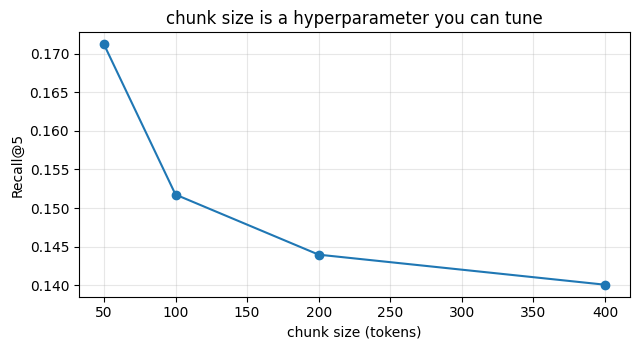

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(chunk_df["chunk_tokens"], chunk_df["Recall@5"], "o-")
ax.set_xlabel("chunk size (tokens)")
ax.set_ylabel("Recall@5")
ax.set_title("chunk size is a hyperparameter you can tune")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

There is usually a peak rather than a monotonic trend, which is the tradeoff from section 3
made visible. Very small chunks lack context, very large ones dilute the embedding. The best
value depends on your documents and your queries, so it is worth measuring rather than
copying a number from a blog post.

### The generation half

Retrieval has clean metrics. Generation does not, because there is no single correct answer.
The practical options, cheapest first:

- **Refusal rate on unanswerable questions.** Write ten questions the corpus cannot answer
  and count how often the system correctly declines. Cheap, and it catches the worst failure
- **Groundedness.** Is every claim supported by the retrieved text? The word-overlap check in
  section 7 is a weak version of this
- **Human review of a fixed sample.** Slow, and still the most trusted
- **A stronger model as judge.** Common, scalable, and biased in known ways. It tends to
  prefer longer answers and answers written in a style similar to its own

Start with the refusal test. It takes ten minutes and finds the failure that matters most.

In [28]:
unanswerable = [
    "Does the company have a factory in Vietnam?",
    "What is the CEO's name?",
    "How many units were sold in 2019?",
    "Is this product available in Saudi Arabia?",
    "What is the capital of Brazil?",
]

refusals = 0
for q in unanswerable:
    ans, hs = rag_answer(q, min_similarity=0.25)
    refused = "do not cover" in ans.lower() or "not mention" in ans.lower() \
        or "no information" in ans.lower() or not hs
    refusals += refused
    print(f"{'REFUSED ' if refused else 'ANSWERED'} | {q}")
    if not refused:
        show(f"           {ans[:160]}")

print(f"\ncorrect refusals: {refusals}/{len(unanswerable)}")

REFUSED  | Does the company have a factory in Vietnam?
REFUSED  | What is the CEO's name?
REFUSED  | How many units were sold in 2019?
REFUSED  | Is this product available in Saudi Arabia?
REFUSED  | What is the capital of Brazil?

correct refusals: 5/5


Any question answered rather than refused is a bug worth chasing. The two levers are a higher
similarity floor, which refuses more often, and a firmer system prompt.

## 9. Exercise

Roughly 15 minutes.

The Introduction to Generative AI notebook's exercise built **hybrid search**, combining TF-IDF and embedding scores, and found it
beat either alone. Section 8 has just shown that retrieval quality caps the whole RAG system.
Put the two together.

**Task**

1. Build a TF-IDF index over `chunks` using the Week 4 settings
   (`max_features=5000, ngram_range=(1, 2), min_df=5`).
2. Write `hybrid_retrieve(query, k=4, alpha=0.7)` scoring chunks with
   `alpha * embedding_similarity + (1 - alpha) * tfidf_similarity`.
3. Measure Recall@5 for the hybrid against the embedding-only number from
   `retrieval_metrics`, using the same `eval_pairs`.
4. Answer in a comment: does hybrid retrieval help here? Section 8 argued retrieval quality
   caps the system, so what would you expect this to do to answer quality, and how would you
   confirm it?

**Hint:** `sklearn.preprocessing.normalize` on the TF-IDF matrices makes the dot product a
cosine similarity, so both score matrices are on a comparable scale.

In [ ]:
# Your answer here.
#
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import normalize
#
# tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
# chunk_tfidf = normalize(tfidf.fit_transform(chunks))

<details>
<summary>Solution</summary>

```python
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
chunk_tfidf = normalize(tfidf.fit_transform(chunks))

queries = [q for q, _ in eval_pairs]
q_emb = embedder.encode(queries, normalize_embeddings=True, batch_size=64)
q_tfidf = normalize(tfidf.transform(queries))

embed_sim = q_emb @ chunk_emb.T
tfidf_sim = (q_tfidf @ chunk_tfidf.T).toarray()


def recall_at_5(sim):
    ranking = np.argsort(-sim, axis=1)[:, :5]
    return np.mean([len(set(ranking[i]) & set(correct)) > 0
                    for i, (_, correct) in enumerate(eval_pairs)])


rows = []
for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    rows.append({"alpha": alpha, "Recall@5": recall_at_5(alpha * embed_sim + (1 - alpha) * tfidf_sim)})

hyb = pd.DataFrame(rows).set_index("alpha")
display(hyb.round(3))

plt.figure(figsize=(6.5, 3.4))
plt.plot(hyb.index, hyb["Recall@5"], "o-")
plt.axhline(retrieval_metrics["Recall@5"], color="gray", ls="--", label="embeddings alone")
plt.xlabel("alpha (0 = TF-IDF, 1 = embeddings)")
plt.ylabel("Recall@5")
plt.legend(); plt.grid(alpha=0.3); plt.show()
```

**What you should see.** A peak in the middle, usually beating both endpoints, though by less
than in the Introduction to Generative AI notebook. The reason is that these queries and chunks come from the same product, so the
vocabulary is narrow and TF-IDF has less distinctive signal to contribute than it did across
a diverse corpus.

**On the second question.** Better retrieval should raise the ceiling on answer quality, but
it does not guarantee better answers, and this is the important point. If Recall@5 was already
high, the correct chunk was usually being found and the remaining errors belong to the
generator. Improving retrieval from 0.90 to 0.93 cannot fix an answer that ignored a chunk it
was given.

To confirm it you would have to measure the generation half: rerun the refusal test, and
sample answers with and without hybrid retrieval for human comparison. Which is the whole
argument of section 8. Optimising the half that is easy to measure, because it is easy to
measure, is a trap.

</details>

## 10. Where this sits in practice

**RAG is the default way to put an LLM on your own data**

The alternative is fine-tuning, and for factual knowledge it is usually the wrong tool. RAG
updates instantly when a document changes, cites its sources, costs nothing to retrain, and
lets you remove a document and have it genuinely gone. Fine-tuning bakes information into
weights where it cannot be cited, updated or removed. Fine-tuning is for changing behaviour
and format. Retrieval is for supplying knowledge.

**What production adds to this notebook**

The architecture here is complete and real, but three things scale up. A **vector database**
such as FAISS, Chroma, Qdrant or pgvector replaces the NumPy matrix multiply once you have
more vectors than fit comfortably in memory, adding approximate search that trades a little
recall for large speed gains. A **reranker**, a small cross-encoder model, rescores the top 50
retrieved chunks and keeps the best 5, which is usually the single highest-value addition to
a basic RAG system. And **hybrid search**, from the exercise, is standard rather than optional.

Everything else in a production system is the evaluation and monitoring from section 8.

**The frameworks**

LangChain and LlamaIndex wrap what this notebook built by hand: loaders, splitters, vector
store adapters and retrieval chains. They save real time once your sources are messy and
varied. Adopt one when the plumbing genuinely hurts, not before, and note that you now know
what it is doing underneath, which is what makes debugging it possible.

**The judgement worth keeping**

RAG makes a model answer from your documents. It does not make the model correct, and it does
not make retrieval find the right passage. Both halves fail, they fail differently, and the
skill is telling them apart. That is why section 8 is the part to remember.

## 11. Further reading

- [Lewis et al., Retrieval-Augmented Generation for Knowledge-Intensive NLP
  Tasks](https://arxiv.org/abs/2005.11401) The original RAG paper. Worth reading for the
  framing of parametric memory, what is in the weights, against non-parametric memory, what is
  in the index, which is the distinction underneath the fine-tuning comparison above.

- [Sentence Transformers: semantic search](https://sbert.net/examples/applications/semantic-search/README.html)
  Practical guidance on scaling the retrieval half, including when approximate search and
  rerankers start to matter.

- [Ragas documentation](https://docs.ragas.io/) An evaluation framework built specifically for
  RAG, with implementations of faithfulness, answer relevance and context precision. The
  metric definitions are a good guide to what is worth measuring even if you do not adopt the
  library.

- [Pinecone's chunking strategies guide](https://www.pinecone.io/learn/chunking-strategies/)
  A practical survey of the chunking decision from section 3, covering fixed-size, recursive,
  sentence-aware and semantic splitting, with guidance on when each suits.